In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
#Importation du fichier
import pandas as pd
import numpy as np 
df=pd.read_csv("/home/mariama-oury/Documents/Data_Flow360/Projet-Dataflow360/notebooks/mobile_money_credit_scoring_5000.csv")
df.head()

,client_id,age,type_activite,anciennete_compte_mois,nb_transactions_90j,montant_transactions_90j,montant_entrees_90j,montant_sorties_90j,solde_moyen_90j,regularite_revenus,stabilite_flux,nombre_credits_precedents,taux_remboursement,nombre_credits_en_retard,nombre_credits_impayes,montant_credit_demande,duree_credit_demande,eligibilite
0,MM648358,28,artisan,14,7,33528,20738,16388,2098,51.0,47.3,0,NaN,0,0,5000,6,eligible
1,MM633076,32,independant,32,64,4762551,2783548,2295792,556269,83.5,59.0,2,98.7,1,0,1003000,12,eligible
2,MM338907,23,etudiant,12,15,136815,45370,43705,1924,4.9,21.2,2,62.7,1,1,8000,6,non_eligible
3,MM679391,38,agriculteur,1,11,262589,202404,280283,29667,57.7,68.7,0,NaN,0,0,12000,3,eligible
4,MM465013,34,salarie,35,24,317589,145984,123411,54772,67.9,80.3,0,NaN,0,0,23000,3,eligible


In [6]:
df.head(100)

,client_id,age,type_activite,anciennete_compte_mois,nb_transactions_90j,montant_transactions_90j,montant_entrees_90j,montant_sorties_90j,solde_moyen_90j,regularite_revenus,stabilite_flux,nombre_credits_precedents,taux_remboursement,nombre_credits_en_retard,nombre_credits_impayes,montant_credit_demande,duree_credit_demande,eligibilite
0,MM648358,28,artisan,14,7,33528,20738,16388,2098,51.0,47.3,0,NaN,0,0,5000,6,eligible
1,MM633076,32,independant,32,64,4762551,2783548,2295792,556269,83.5,59.0,2,98.7,1,0,1003000,12,eligible
2,MM338907,23,etudiant,12,15,136815,45370,43705,1924,4.9,21.2,2,62.7,1,1,8000,6,non_eligible
3,MM679391,38,agriculteur,1,11,262589,202404,280283,29667,57.7,68.7,0,NaN,0,0,12000,3,eligible
4,MM465013,34,salarie,35,24,317589,145984,123411,54772,67.9,80.3,0,NaN,0,0,23000,3,eligible
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,MM556289,40,agriculteur,6,22,135904,27900,23314,5430,54.6,83.6,0,NaN,0,0,13000,12,non_eligible
96,MM387243,32,commercant,13,36,285296,181268,201774,32431,66.9,36.7,0,NaN,0,0,36000,6,eligible
97,MM231051,37,salarie,24,24,193794,182906,214808,6570,67.1,76.4,0,NaN,0,0,9000,2,eligible
98,MM111703,40,salarie,9,16,175467,81037,97236,5073,72.9,52.7,0,NaN,0,0,51000,12,eligible


In [7]:
# Affiche les modalités avec leur nombre d'apparitions (inclut les NaN)
print(df['eligibilite'].value_counts(dropna=False))

eligibilite
eligible        3100
non_eligible    1900
Name: count, dtype: int64


In [8]:
#Nombre de lignes et de colonnes du dataset
df.shape

(5000, 18)

In [9]:
#Valeurs manquantes
df.isnull().sum()


client_id                       0
age                             0
type_activite                   0
anciennete_compte_mois          0
nb_transactions_90j             0
montant_transactions_90j        0
montant_entrees_90j             0
montant_sorties_90j             0
solde_moyen_90j                 0
regularite_revenus              0
stabilite_flux                  0
nombre_credits_precedents       0
taux_remboursement           1959
nombre_credits_en_retard        0
nombre_credits_impayes          0
montant_credit_demande          0
duree_credit_demande            0
eligibilite                     0
dtype: int64

In [10]:
# Liste des catégories uniques
print(df["retard_moyen_jours"].unique())

KeyError: 'retard_moyen_jours'

In [ ]:
# Étape 1 : Créer une colonne indicateur (1 = Nouveau client sans historique, 0 = Ancien client)
df["sans_historique_credit"] = df["retard_moyen_jours"].isna().astype(int)

# Étape 2 : Remplacer les NaN par 0
df["retard_moyen_jours"] = df["retard_moyen_jours"].fillna(0)
df["taux_remboursement"] = df["taux_remboursement"].fillna(0)

# Étape 3 : Vérifier qu'il n'y a plus aucun trou
print(df[["retard_moyen_jours", "taux_remboursement"]].isnull().sum())

retard_moyen_jours    0
taux_remboursement    0
dtype: int64


In [ ]:
#Valeurs manquantes
df.isnull().sum()

client_id                       0
age                             0
type_activite                   0
anciennete_compte_mois          0
nb_transactions_90j             0
montant_transactions_90j        0
montant_entrees_90j             0
montant_sorties_90j             0
solde_moyen_90j                 0
regularite_revenus              0
stabilite_flux                  0
nombre_credits_precedents       0
taux_remboursement           1959
nombre_credits_en_retard        0
nombre_credits_impayes          0
montant_credit_demande          0
duree_credit_demande            0
eligibilite                     0
dtype: int64

In [ ]:
# Compter le nombre de lignes doublons
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons stricts : {nb_doublons}")

Nombre de doublons stricts : 0


In [ ]:
#Verification des types de variables 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_id                  5000 non-null   str    
 1   age                        5000 non-null   int64  
 2   type_activite              5000 non-null   str    
 3   anciennete_compte_mois     5000 non-null   int64  
 4   nb_transactions_90j        5000 non-null   int64  
 5   montant_transactions_90j   5000 non-null   int64  
 6   montant_entrees_90j        5000 non-null   int64  
 7   montant_sorties_90j        5000 non-null   int64  
 8   solde_moyen_90j            5000 non-null   int64  
 9   regularite_revenus         5000 non-null   float64
 10  stabilite_flux             5000 non-null   float64
 11  nombre_credits_precedents  5000 non-null   int64  
 12  taux_remboursement         3041 non-null   float64
 13  nombre_credits_en_retard   5000 non-null   int64  
 14  nom

In [ ]:
#Verification des valeurs aberrantes
df.describe()

,age,anciennete_compte_mois,nb_transactions_90j,montant_transactions_90j,montant_entrees_90j,montant_sorties_90j,solde_moyen_90j,regularite_revenus,stabilite_flux,nombre_credits_precedents,taux_remboursement,nombre_credits_en_retard,nombre_credits_impayes,montant_credit_demande,duree_credit_demande
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000,3041.000000,5000.000000,5000.000000,5.000000e+03,5000.000000
mean,37.012400,23.384000,22.728200,3.163068e+05,1.754958e+05,1.619388e+05,2.194607e+04,52.939220,54.066860,1.659400,90.688984,0.461600,0.174800,5.378180e+04,4.600000
std,11.274417,22.257817,20.903553,5.729770e+05,3.851702e+05,3.504425e+05,5.311361e+04,27.577896,22.177864,1.769751,17.815675,0.804646,0.475279,1.433623e+05,3.426711
min,18.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.100000,2.300000,0.000000,0.200000,0.000000,0.000000,5.000000e+03,1.000000
25%,29.000000,9.000000,9.000000,6.307825e+04,2.608150e+04,2.422075e+04,2.430000e+03,28.900000,36.600000,0.000000,92.100000,0.000000,0.000000,6.000000e+03,2.000000
50%,36.000000,17.000000,17.000000,1.490250e+05,6.944800e+04,6.523100e+04,6.912500e+03,54.700000,55.400000,1.000000,99.700000,0.000000,0.000000,1.600000e+04,3.000000
75%,45.000000,30.000000,29.000000,3.495335e+05,1.764850e+05,1.641395e+05,1.915350e+04,77.125000,71.925000,3.000000,100.000000,1.000000,0.000000,4.500000e+04,6.000000
max,80.000000,150.000000,280.000000,1.215248e+07,8.402684e+06,8.055644e+06,1.175671e+06,99.400000,98.300000,12.000000,100.000000,7.000000,4.000000,3.000000e+06,12.000000


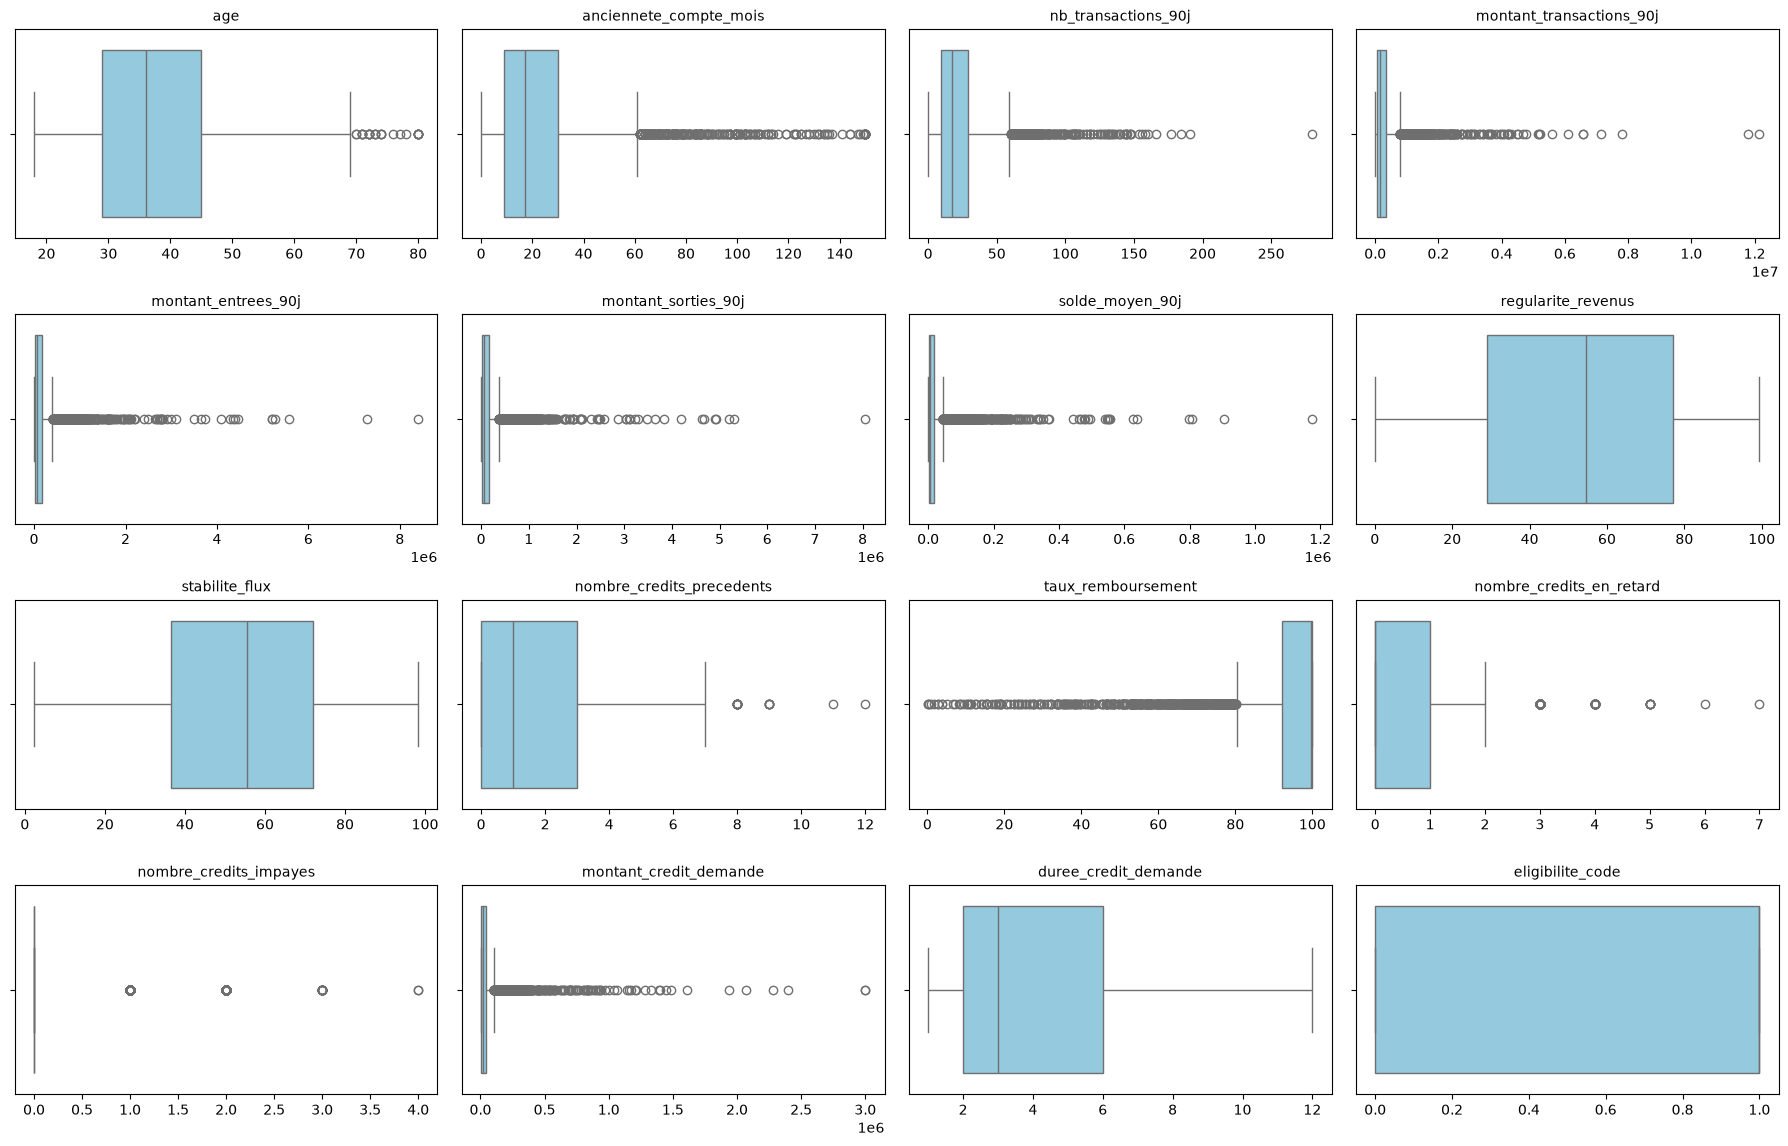

In [17]:
# Verification des valeurs aberrantes
# 1. Sélection de toutes les colonnes numériques
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Création d'une grille de graphiques (ex: 5 lignes x 4 colonnes = 20 variables)
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(18, 14))
axes = axes.flatten()  # Applatir la grille pour boucler facilement dessus

# 3. Boucle pour afficher chaque boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Masquer les sous-graphiques vides s'il y a moins de 20 variables
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

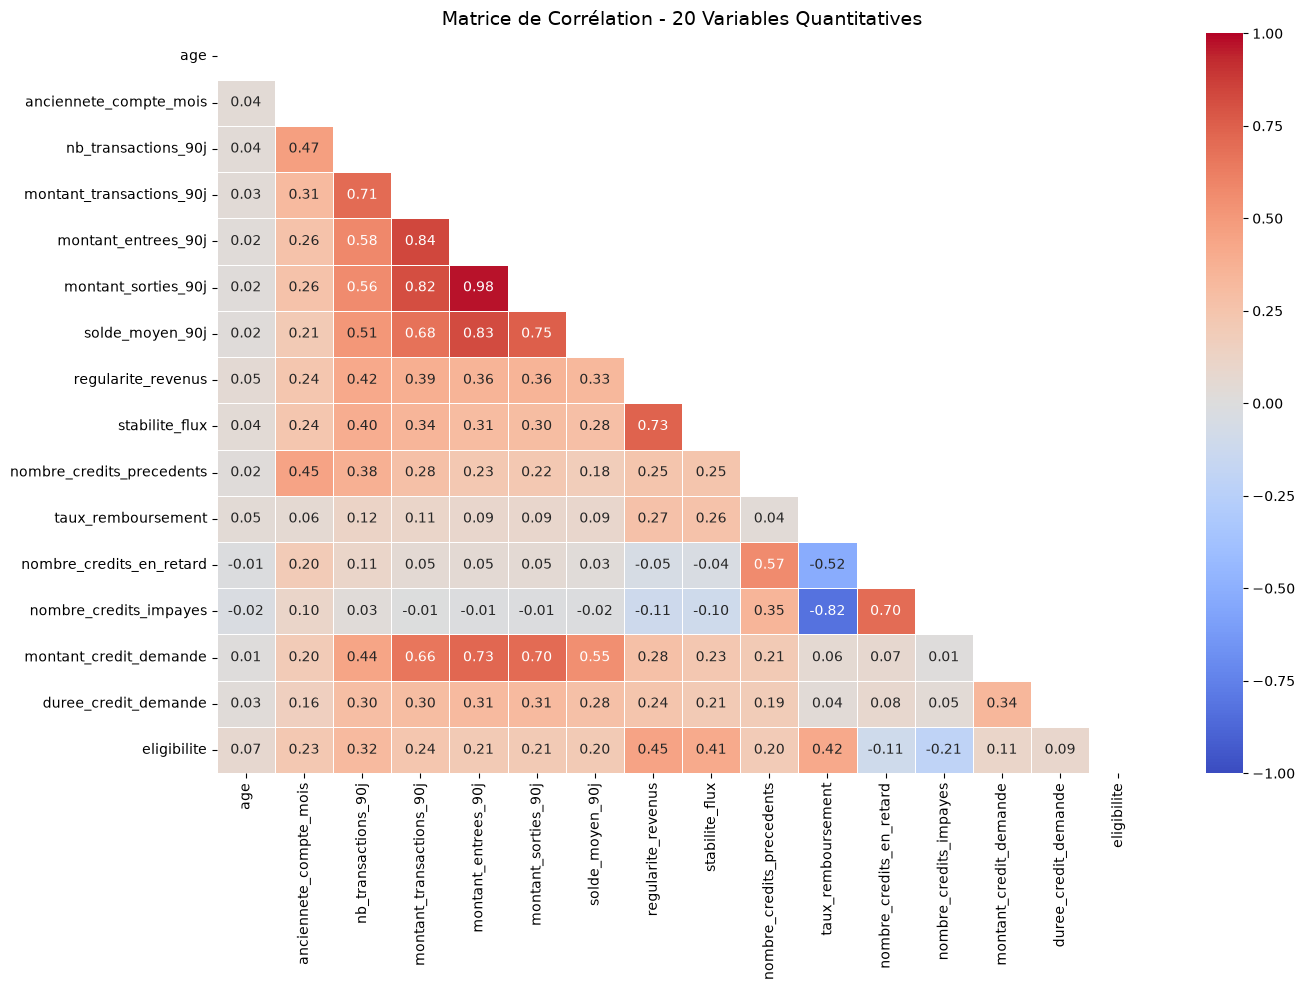

--- Paires de variables fortement corrélées (|r| >= 0.70) ---
                   Variable 1                Variable 2  Correlation
69        montant_entrees_90j       montant_sorties_90j     0.975387
52   montant_transactions_90j       montant_entrees_90j     0.839890
70        montant_entrees_90j           solde_moyen_90j     0.826580
53   montant_transactions_90j       montant_sorties_90j     0.819753
86        montant_sorties_90j           solde_moyen_90j     0.752407
120        regularite_revenus            stabilite_flux     0.734506
77        montant_entrees_90j    montant_credit_demande     0.726353
35        nb_transactions_90j  montant_transactions_90j     0.705798
93        montant_sorties_90j    montant_credit_demande     0.704066
172        taux_remboursement    nombre_credits_impayes    -0.824632


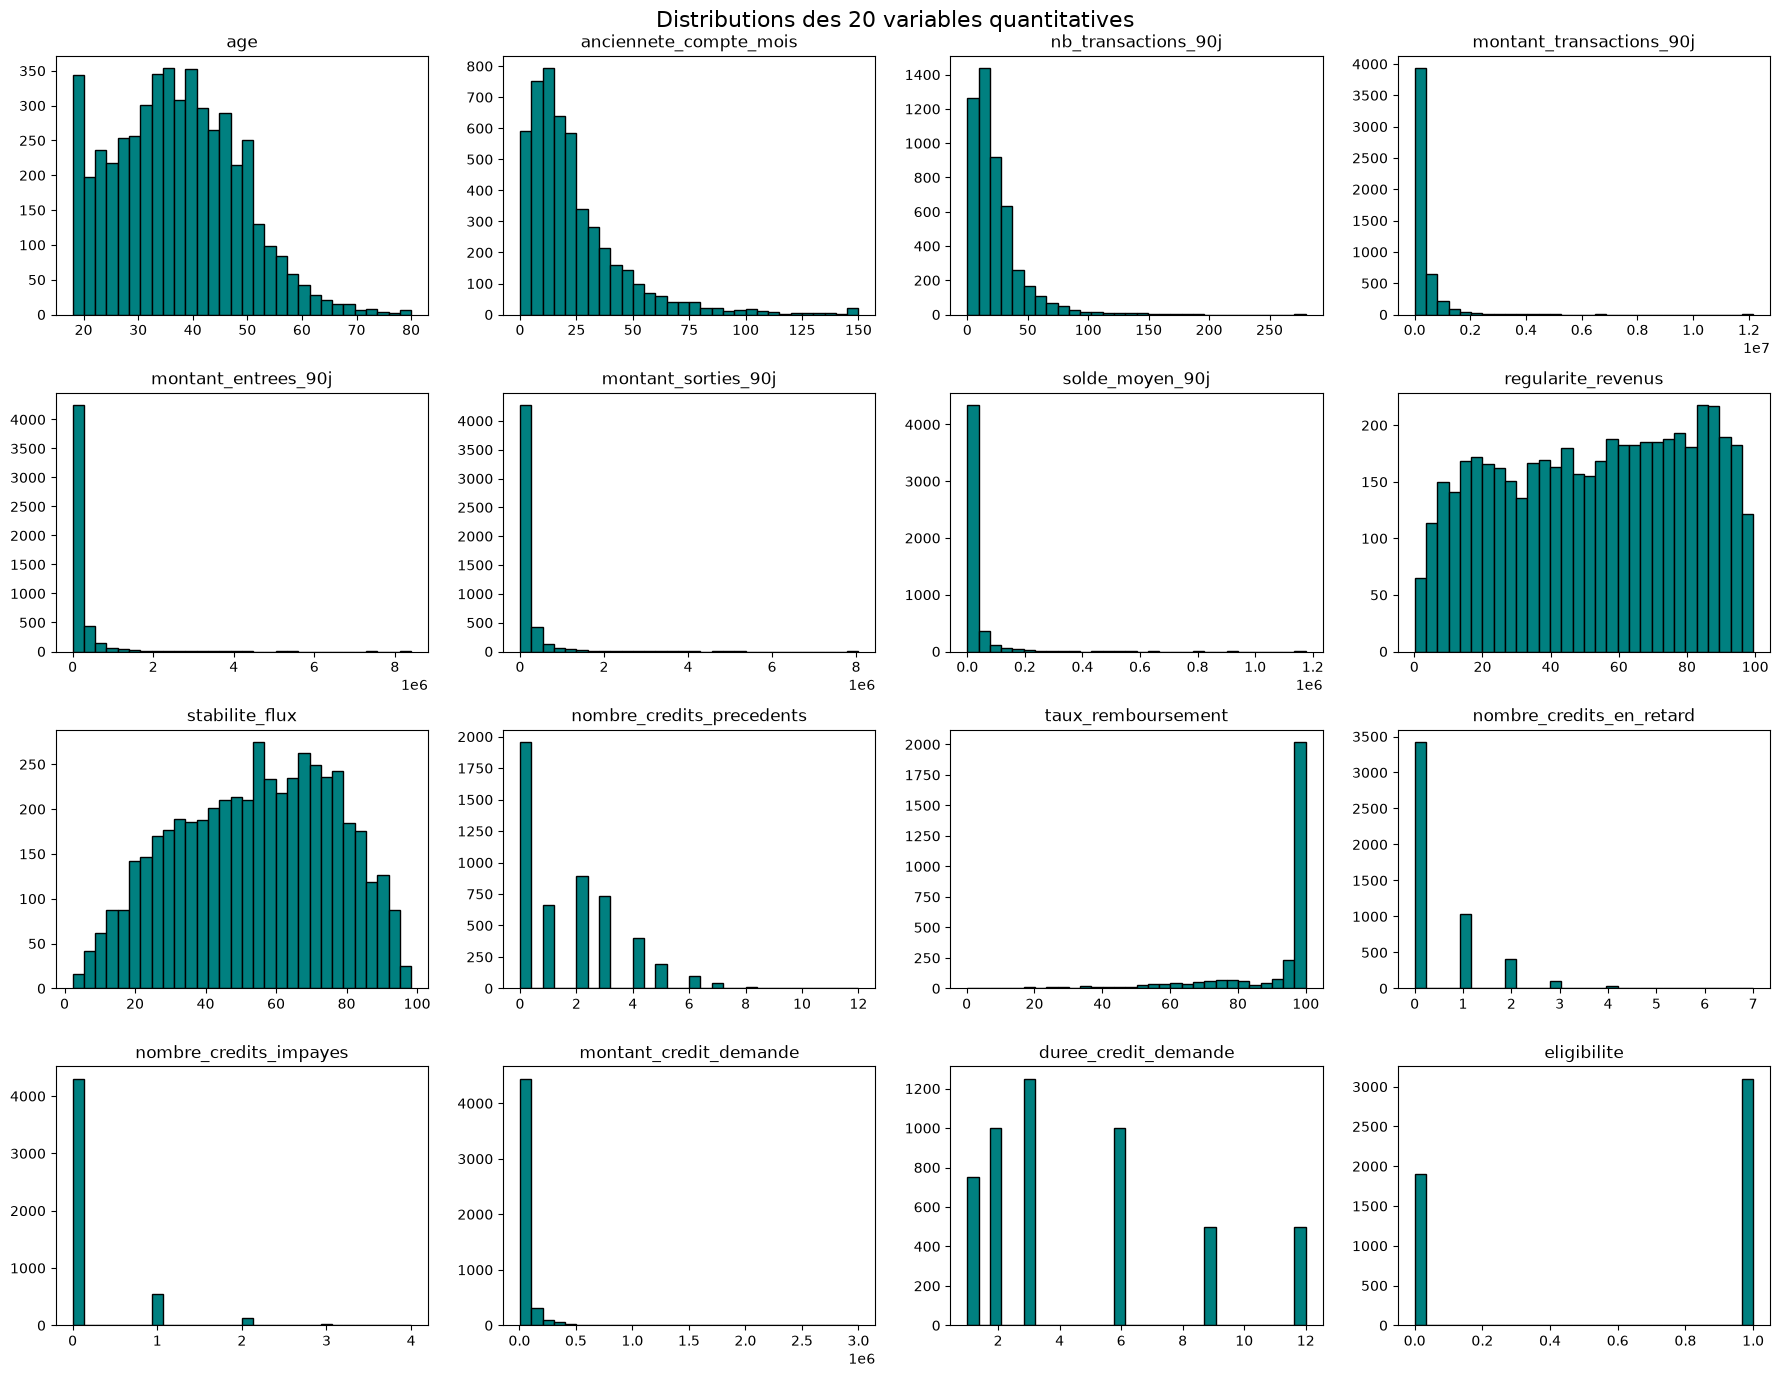

In [ ]:

# ---------------------------------------------------------
# A. Matrice de Corrélation globale
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)

#Masque pour cacher la moitié supérieure symétrique (plus lisible)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    linewidths=0.5
)
plt.title("Matrice de Corrélation - 20 Variables Quantitatives", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B. Détection automatique des fortes colinéarités (|r| >= 0.70)
# ---------------------------------------------------------
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corr = upper_tri.stack().reset_index()
strong_corr.columns = ['Variable 1', 'Variable 2', 'Correlation']
strong_corr = strong_corr[strong_corr['Correlation'].abs() >= 0.70].sort_values(by='Correlation', ascending=False)

print("--- Paires de variables fortement corrélées (|r| >= 0.70) ---")
print(strong_corr)

# ---------------------------------------------------------
# C. Distribution de toutes les variables (Histogames + KDE)
# ---------------------------------------------------------
df.hist(figsize=(18, 14), bins=30, color='teal', edgecolor='black', grid=False)
plt.suptitle("Distributions des 20 variables quantitatives", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# 4. Encodage sécurisé avec replace
df['eligibilite'] = df['eligibilite'].replace({'eligible': 1, 'non_eligible': 0})

In [ ]:
# 5. Vérifier qu'il n'y a plus de NaN
print("\nModalités après conversion :")
print(df['eligibilite'].value_counts(dropna=False))


Modalités après conversion :
eligibilite
1    3100
0    1900
Name: count, dtype: int64


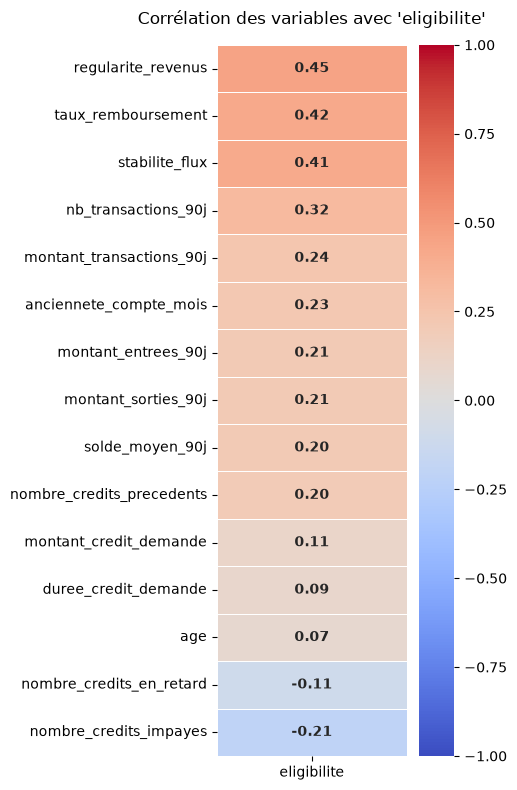

In [ ]:
# 1. S'assurer que la colonne est bien au format numérique
df['eligibilite'] = df['eligibilite'].astype(int)

# 2. Recalcul de la matrice de corrélation
corr_matrix = df.corr(numeric_only=True)

# 3. Extraction et tri
corr_defaut = corr_matrix[['eligibilite']].drop('eligibilite').sort_values(by='eligibilite', ascending=False)

# 4. Affichage graphique
plt.rcdefaults()
plt.figure(figsize=(5, 8))

sns.heatmap(
    corr_defaut, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1,
    cbar=True,
    linewidths=0.5,
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title("Corrélation des variables avec 'eligibilite'", pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Proportions en pourcentage (%)
print("\n--- Proportions (%) ---")
print(df["eligibilite"].value_counts(normalize=True) * 100)


--- Proportions (%) ---
eligibilite
1    62.0
0    38.0
Name: proportion, dtype: float64


In [ ]:
# 1. Effectifs bruts (nombre de lignes)
print("--- Effectifs bruts ---")
print(df["eligibilite"].value_counts())

--- Effectifs bruts ---
eligibilite
1    3100
0    1900
Name: count, dtype: int64


/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6969/808170310.py:37: FutureWarning: 

Passin

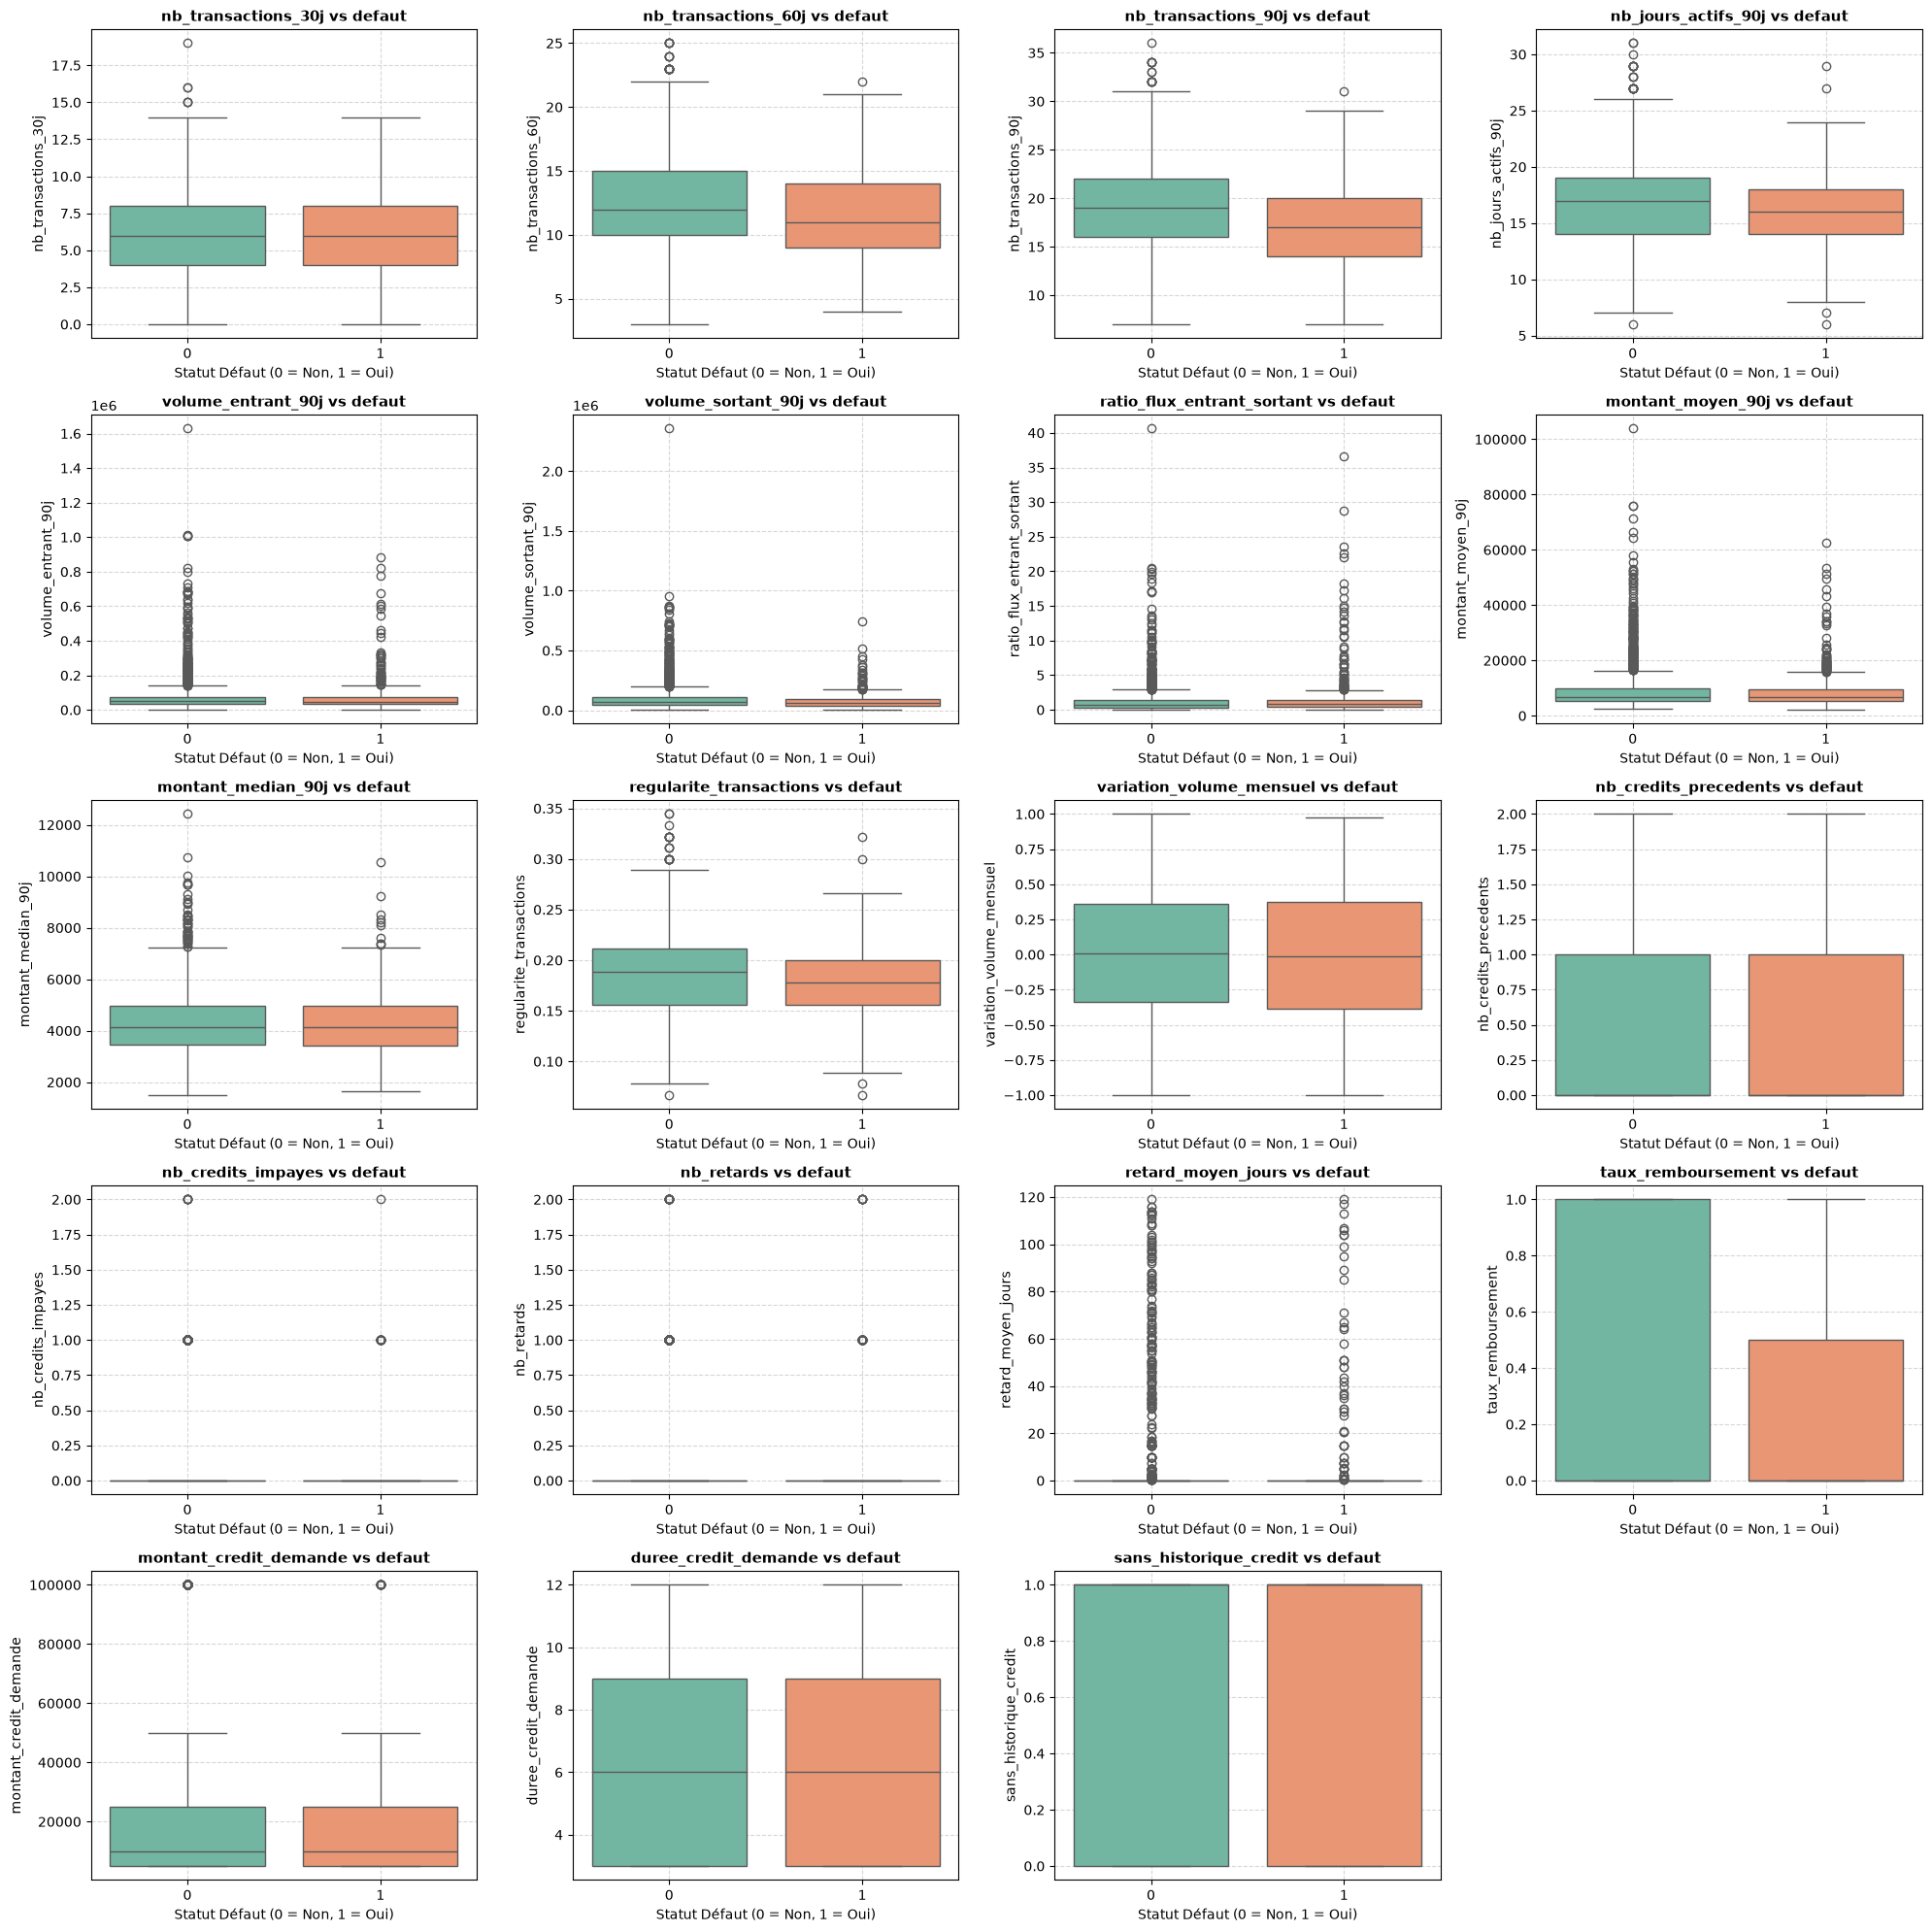

In [ ]:
import math

# 1. Liste de toutes vos variables numériques (excluant 'defaut')
variables_num = [
    'nb_transactions_30j',
    'nb_transactions_60j',
    'nb_transactions_90j',
    'nb_jours_actifs_90j',
    'volume_entrant_90j',
    'volume_sortant_90j',
    'ratio_flux_entrant_sortant',
    'montant_moyen_90j',
    'montant_median_90j',
    'regularite_transactions',
    'variation_volume_mensuel',
    'nb_credits_precedents',
    'nb_credits_impayes',
    'nb_retards',
    'retard_moyen_jours',
    'taux_remboursement',
    'montant_credit_demande',
    'duree_credit_demande',
    'sans_historique_credit',
]

# 2. Configuration de la grille de graphiques (ex: 5 lignes x 4 colonnes)
n_vars = len(variables_num)
n_cols = 4
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()  # Aplatir la grille pour faciliter la boucle

# 3. Génération des Boxplots comparatifs par variable
for i, col in enumerate(variables_num):
    if col in df.columns:
        sns.boxplot(
            data=df,
            x='defaut',
            y=col,
            ax=axes[i],
            palette='Set2',
            showfliers=True,  # Met à False si tu veux cacher les outliers extrêmes
        )
        axes[i].set_title(f'{col} vs defaut', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Statut Défaut (0 = Non, 1 = Oui)')
        axes[i].set_ylabel(col)
        axes[i].grid(True, linestyle='--', alpha=0.5)

# 4. Supprimer les axes inutilisés dans la grille
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Affiche la médiane exacte du taux de remboursement pour chaque groupe
df.groupby('defaut')['taux_remboursement'].median()

defaut
0    0.0
1    0.0
Name: taux_remboursement, dtype: float64

In [ ]:
print(df["taux_remboursement"].unique())

[0.  1.  0.5]


In [ ]:
#Valeurs manquantes
df.isnull().sum()

id_credit                     0
nb_transactions_30j           0
nb_transactions_60j           0
nb_transactions_90j           0
nb_jours_actifs_90j           0
volume_entrant_90j            0
volume_sortant_90j            0
ratio_flux_entrant_sortant    0
montant_moyen_90j             0
montant_median_90j            0
regularite_transactions       0
variation_volume_mensuel      0
nb_credits_precedents         0
nb_credits_impayes            0
nb_retards                    0
retard_moyen_jours            0
taux_remboursement            0
montant_credit_demande        0
duree_credit_demande          0
defaut                        0
sans_historique_credit        0
dtype: int64

In [ ]:
#Convertir le df en csv
df.to_csv("dataset_credit_clean.csv", index=False)

In [ ]:
from scipy import stats

In [12]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["type_activite"], df["eligibilite"])

chi2, p, ddl, expected = chi2_contingency(table)

print("Chi² :", chi2)
print("p-value :", p)

Chi² : 425.7742275464434
p-value : 8.010321692955207e-89


In [13]:
n = table.to_numpy().sum()
r, k = table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1))
)

print("Cramér's V :", cramers_v)

Cramér's V : 0.29181303176741213


In [14]:
from scipy.stats import pearsonr

# Encodage de la cible
df["eligibilite_code"] = df["eligibilite"].map({
    "non_eligible": 0,
    "eligible": 1
})

# Variables quantitatives
variables_quantitatives = df.select_dtypes(include="number").columns.tolist()

# Retirer les identifiants et la cible
variables_quantitatives = [
    col for col in variables_quantitatives
    if col not in ["client_id", "eligibilite_code"]
]

# Calcul des corrélations et p-values
resultats = []

for variable in variables_quantitatives:
    # Retirer les valeurs manquantes pour cette paire
    data = df[[variable, "eligibilite_code"]].dropna()

    correlation, p_value = pearsonr(
        data[variable],
        data["eligibilite_code"]
    )

    resultats.append({
        "variable": variable,
        "correlation": correlation,
        "p_value": p_value
    })

# Transformer en DataFrame
resultats = pd.DataFrame(resultats)

# Trier par valeur absolue de la corrélation
resultats["abs_correlation"] = resultats["correlation"].abs()

resultats = resultats.sort_values(
    "abs_correlation",
    ascending=False
)

print(resultats)

                     variable  correlation        p_value  abs_correlation
7          regularite_revenus     0.448452  5.213179e-246         0.448452
10         taux_remboursement     0.418282  4.192533e-129         0.418282
8              stabilite_flux     0.410471  1.558276e-202         0.410471
2         nb_transactions_90j     0.317400  2.022821e-117         0.317400
3    montant_transactions_90j     0.240885   6.211360e-67         0.240885
1      anciennete_compte_mois     0.226069   5.788486e-59         0.226069
4         montant_entrees_90j     0.210298   4.328777e-51         0.210298
12     nombre_credits_impayes    -0.208852   2.125724e-50         0.208852
5         montant_sorties_90j     0.206648   2.346480e-49         0.206648
6             solde_moyen_90j     0.203175   9.776879e-48         0.203175
9   nombre_credits_precedents     0.201381   6.534866e-47         0.201381
11   nombre_credits_en_retard    -0.107015   3.274018e-14         0.107015
13     montant_credit_dem

In [15]:
variables_quantitatives = [
    "age",
    "anciennete_compte_mois",
    "nb_transactions_90j",
    "montant_transactions_90j",
    "montant_entrees_90j",
    "montant_sorties_90j",
    "solde_moyen_90j",
    "regularite_revenus",
    "nombre_credits_precedents",
    "taux_remboursement",
    "nombre_credits_en_retard",
    "nombre_credits_impayes",
    "montant_credit_demande",
    "duree_credit_demande",
    "stabilite_flux"
]

comparaison = df.groupby("eligibilite")[variables_quantitatives].mean().T

print(comparaison)

eligibilite                     eligible   non_eligible
age                            37.640323      35.987895
anciennete_compte_mois         27.322903      16.957368
nb_transactions_90j            27.921935      14.254211
montant_transactions_90j   424350.402581  140025.163158
montant_entrees_90j        238903.242581   72041.538421
montant_sorties_90j        218628.141935   69445.657895
solde_moyen_90j             30393.594839    8163.276842
regularite_revenus             62.620419      37.143579
nombre_credits_precedents       1.938387       1.204211
taux_remboursement             95.557860      79.287253
nombre_credits_en_retard        0.394194       0.571579
nombre_credits_impayes          0.097097       0.301579
montant_credit_demande      65719.032258   34305.263158
duree_credit_demande            4.849032       4.193684
stabilite_flux                 61.193000      42.440000


In [16]:
from scipy.stats import mannwhitneyu

resultats_mann_whitney = []

for variable in variables_quantitatives:

    groupe_eligible = df.loc[
        df["eligibilite"] == "eligible",
        variable
    ].dropna()

    groupe_non_eligible = df.loc[
        df["eligibilite"] == "non_eligible",
        variable
    ].dropna()

    statistique, p_value = mannwhitneyu(
        groupe_eligible,
        groupe_non_eligible,
        alternative="two-sided"
    )

    resultats_mann_whitney.append({
        "variable": variable,
        "U": statistique,
        "p_value": p_value
    })

resultats_mann_whitney = pd.DataFrame(resultats_mann_whitney)

resultats_mann_whitney = resultats_mann_whitney.sort_values(
    "p_value"
)

print(resultats_mann_whitney)

                     variable          U        p_value
7          regularite_revenus  4500401.5  2.439746e-216
4         montant_entrees_90j  4489461.5  2.459046e-213
3    montant_transactions_90j  4487228.0  1.002931e-212
5         montant_sorties_90j  4435269.0  9.013497e-199
6             solde_moyen_90j  4430014.0  2.185508e-197
14             stabilite_flux  4363372.0  2.989465e-180
2         nb_transactions_90j  4310444.0  2.611101e-167
9          taux_remboursement  1401370.5   4.779198e-95
12     montant_credit_demande  3870930.5   7.017697e-79
1      anciennete_compte_mois  3865805.5   3.823078e-77
8   nombre_credits_precedents  3663126.5   3.730102e-51
11     nombre_credits_impayes  2525141.0   3.877687e-45
13       duree_credit_demande  3251625.0   2.851525e-10
0                         age  3237803.0   3.376450e-09
10   nombre_credits_en_retard  2736630.0   2.716810e-07


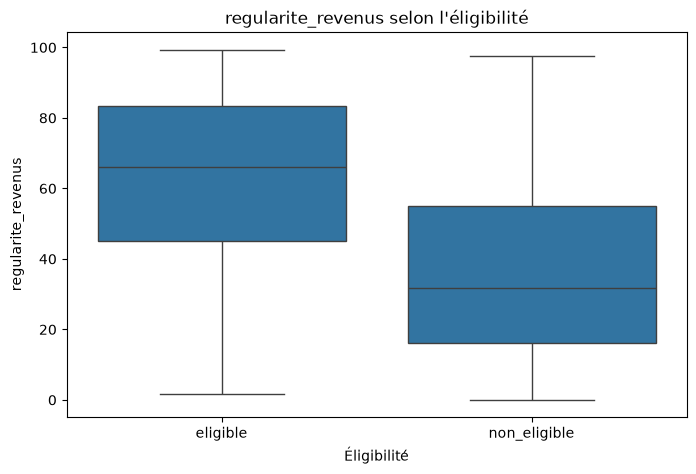

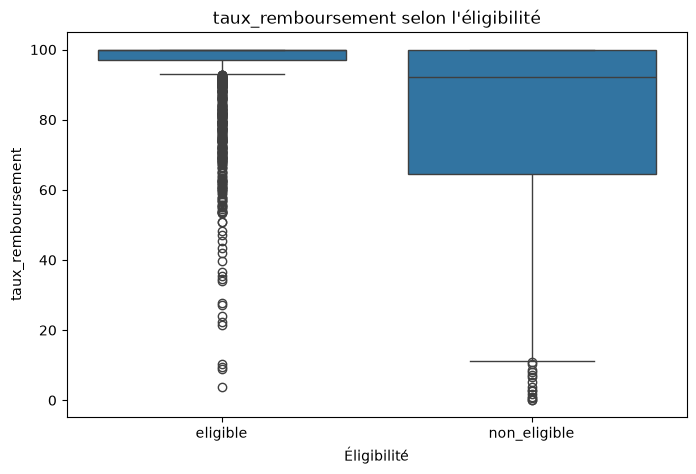

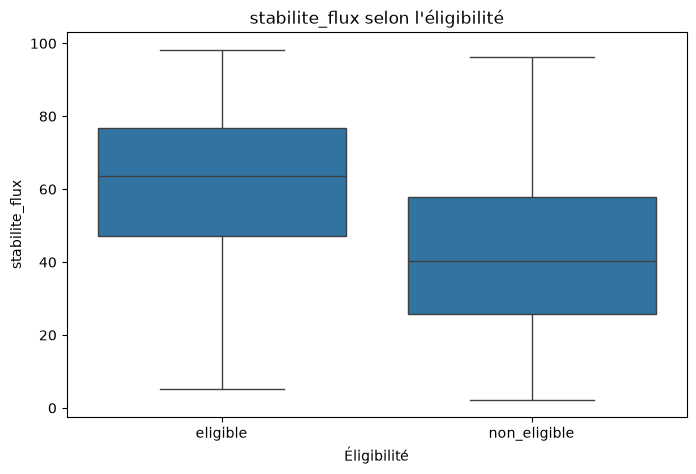

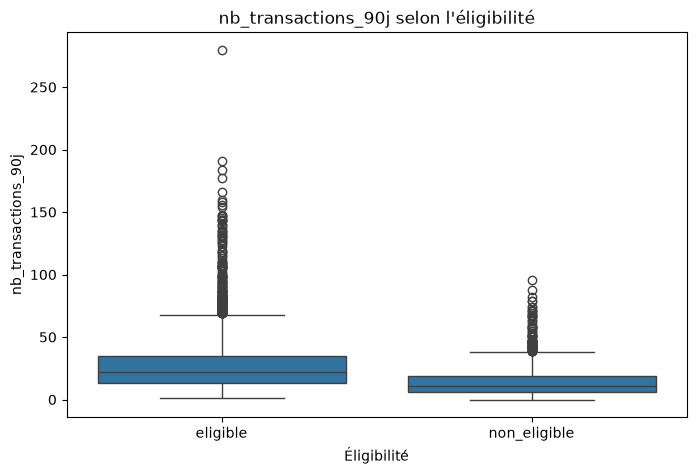

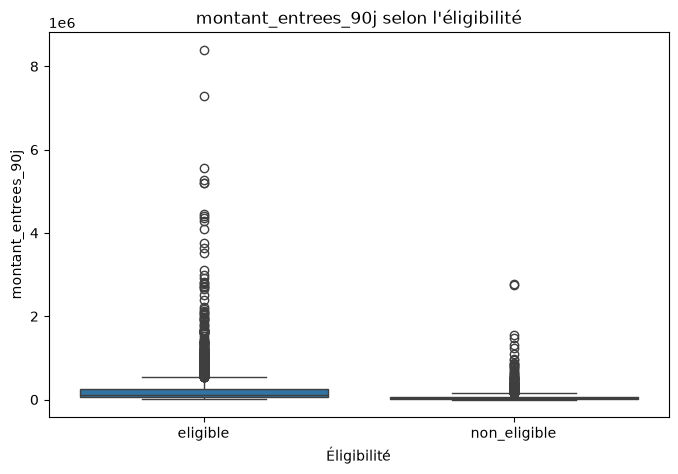

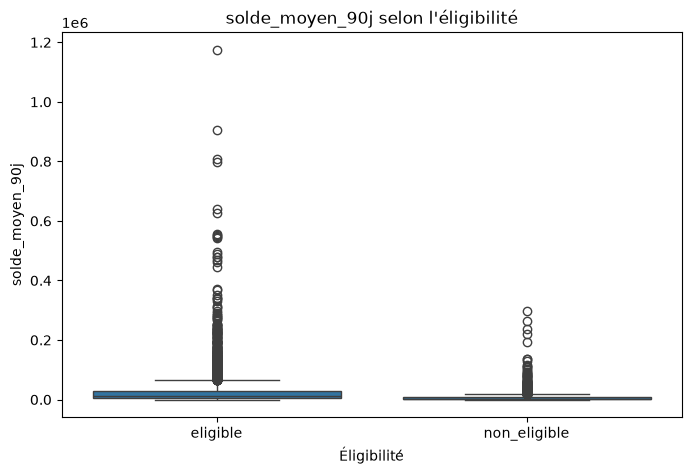

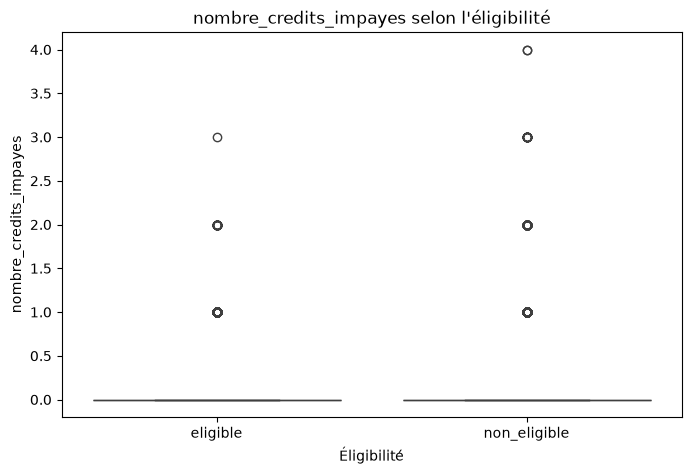

In [18]:
variables_importantes = [
    "regularite_revenus",
    "taux_remboursement",
    "stabilite_flux",
    "nb_transactions_90j",
    "montant_entrees_90j",
    "solde_moyen_90j",
    "nombre_credits_impayes"
]

for variable in variables_importantes:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="eligibilite",
        y=variable
    )

    plt.title(f"{variable} selon l'éligibilité")
    plt.xlabel("Éligibilité")
    plt.ylabel(variable)

    plt.show()

In [19]:
# Nombre de valeurs manquantes
valeurs_manquantes = df.isna().sum()

# Pourcentage de valeurs manquantes
pourcentage_manquant = (df.isna().mean() * 100).round(2)

# Tableau récapitulatif
manquants = pd.DataFrame({
    "nombre_manquant": valeurs_manquantes,
    "pourcentage_manquant": pourcentage_manquant
})

# Garder uniquement les variables qui ont des valeurs manquantes
manquants = manquants[manquants["nombre_manquant"] > 0]

print(manquants)

                    nombre_manquant  pourcentage_manquant
taux_remboursement             1959                 39.18


In [20]:
print(
    df[df["taux_remboursement"].isna()]
    ["nombre_credits_precedents"]
    .value_counts()
    .sort_index()
)

nombre_credits_precedents
0    1959
Name: count, dtype: int64


In [21]:
print(
    pd.crosstab(
        df["nombre_credits_precedents"],
        df["taux_remboursement"].isna(),
        normalize="index"
    ) * 100
)

taux_remboursement         False  True 
nombre_credits_precedents              
0                            0.0  100.0
1                          100.0    0.0
2                          100.0    0.0
3                          100.0    0.0
4                          100.0    0.0
5                          100.0    0.0
6                          100.0    0.0
7                          100.0    0.0
8                          100.0    0.0
9                          100.0    0.0
11                         100.0    0.0
12                         100.0    0.0


In [22]:
pd.crosstab(
    df["nombre_credits_precedents"] == 0,
    df["eligibilite"],
    normalize="index"
) * 100


eligibilite,eligible,non_eligible
nombre_credits_precedents,,
False,70.075633,29.924367
True,49.464012,50.535988


In [23]:
resultats_outliers = []

for variable in variables_quantitatives:

    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)

    IQR = Q3 - Q1

    borne_inferieure = Q1 - 1.5 * IQR
    borne_superieure = Q3 + 1.5 * IQR

    outliers = (
        (df[variable] < borne_inferieure) |
        (df[variable] > borne_superieure)
    )

    nombre_outliers = outliers.sum()

    pourcentage_outliers = (
        nombre_outliers / len(df) * 100
    )

    resultats_outliers.append({
        "variable": variable,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "borne_inferieure": borne_inferieure,
        "borne_superieure": borne_superieure,
        "nombre_outliers": nombre_outliers,
        "pourcentage_outliers": round(pourcentage_outliers, 2)
    })

resultats_outliers = pd.DataFrame(resultats_outliers)

resultats_outliers = resultats_outliers.sort_values(
    "pourcentage_outliers",
    ascending=False
)

print(resultats_outliers)

                     variable        Q1          Q3         IQR  \
11     nombre_credits_impayes      0.00       0.000       0.000   
6             solde_moyen_90j   2430.00   19153.500   16723.500   
9          taux_remboursement     92.10     100.000       7.900   
12     montant_credit_demande   6000.00   45000.000   39000.000   
4         montant_entrees_90j  26081.50  176485.000  150403.500   
5         montant_sorties_90j  24220.75  164139.500  139918.750   
3    montant_transactions_90j  63078.25  349533.500  286455.250   
1      anciennete_compte_mois      9.00      30.000      21.000   
2         nb_transactions_90j      9.00      29.000      20.000   
10   nombre_credits_en_retard      0.00       1.000       1.000   
0                         age     29.00      45.000      16.000   
8   nombre_credits_precedents      0.00       3.000       3.000   
7          regularite_revenus     28.90      77.125      48.225   
13       duree_credit_demande      2.00       6.000       4.00